In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots

In [2]:
df_tfd_base1 = pd.read_csv('../../cp/results_base1_tfd.csv')
df_tfd_base1 = df_tfd_base1.drop_duplicates(subset=['config','num_trains'])
df_tfd_base1 = df_tfd_base1.assign(planner='tfd', base='base1')

df_tfd_base2 = pd.read_csv('../../cp/results_base2_tfd.csv')
df_tfd_base2 = df_tfd_base2.drop_duplicates(subset=['config','num_trains'])
df_tfd_base2 = df_tfd_base2.assign(planner='tfd', base='base2')

df_tfd = pd.concat([df_tfd_base1, df_tfd_base2])

df_enhsp_base3 = pd.read_csv('../../cp/results_base3_enhsp.csv')
df_enhsp_base3 = df_enhsp_base3.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base3 = df_enhsp_base3.assign(planner='enhsp', base='base3')

df_enhsp_base4 = pd.read_csv('../../cp/results_base4_enhsp.csv')
df_enhsp_base4 = df_enhsp_base4.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base4 = df_enhsp_base4.assign(planner='enhsp', base='base4')

df_enhsp = pd.concat([df_enhsp_base3, df_enhsp_base4])

df_mff_base3 = pd.read_csv('../../cp/results_base3_metricff.csv')
df_mff_base3 = df_mff_base3.drop_duplicates(subset=['config','num_trains'])
df_mff_base3 = df_mff_base3.assign(planner='metricff', base='base3')

df_mff = df_mff_base3.copy()

df_nfd_base3 = pd.read_csv('../../cp/results_base3_nfd.csv')
df_nfd_base3 = df_nfd_base3.drop_duplicates(subset=['config','num_trains'])
df_nfd_base3 = df_nfd_base3.assign(planner='nfd', base='base3')

# df_nfd_base4 = pd.read_csv('../../cp/results_base4_nfd.csv')
# df_nfd_base4 = df_nfd_base4.drop_duplicates(subset=['config','num_trains'])
# df_nfd_base4 = df_nfd_base4.assign(planner='nfd', base='base4')

df_nfd = pd.concat([df_nfd_base3])#, df_nfd_base4])

df_base1 = df_tfd_base1.copy()
df_base2 = df_tfd_base2.copy()
df_base3 = pd.concat([df_enhsp_base3, df_mff_base3, df_nfd_base3])
df_base4 = pd.concat([df_enhsp_base4])#, df_nfd_base4])

df_temporal = pd.concat([df_base1, df_base2])
df_numeric = pd.concat([df_base3, df_base4])


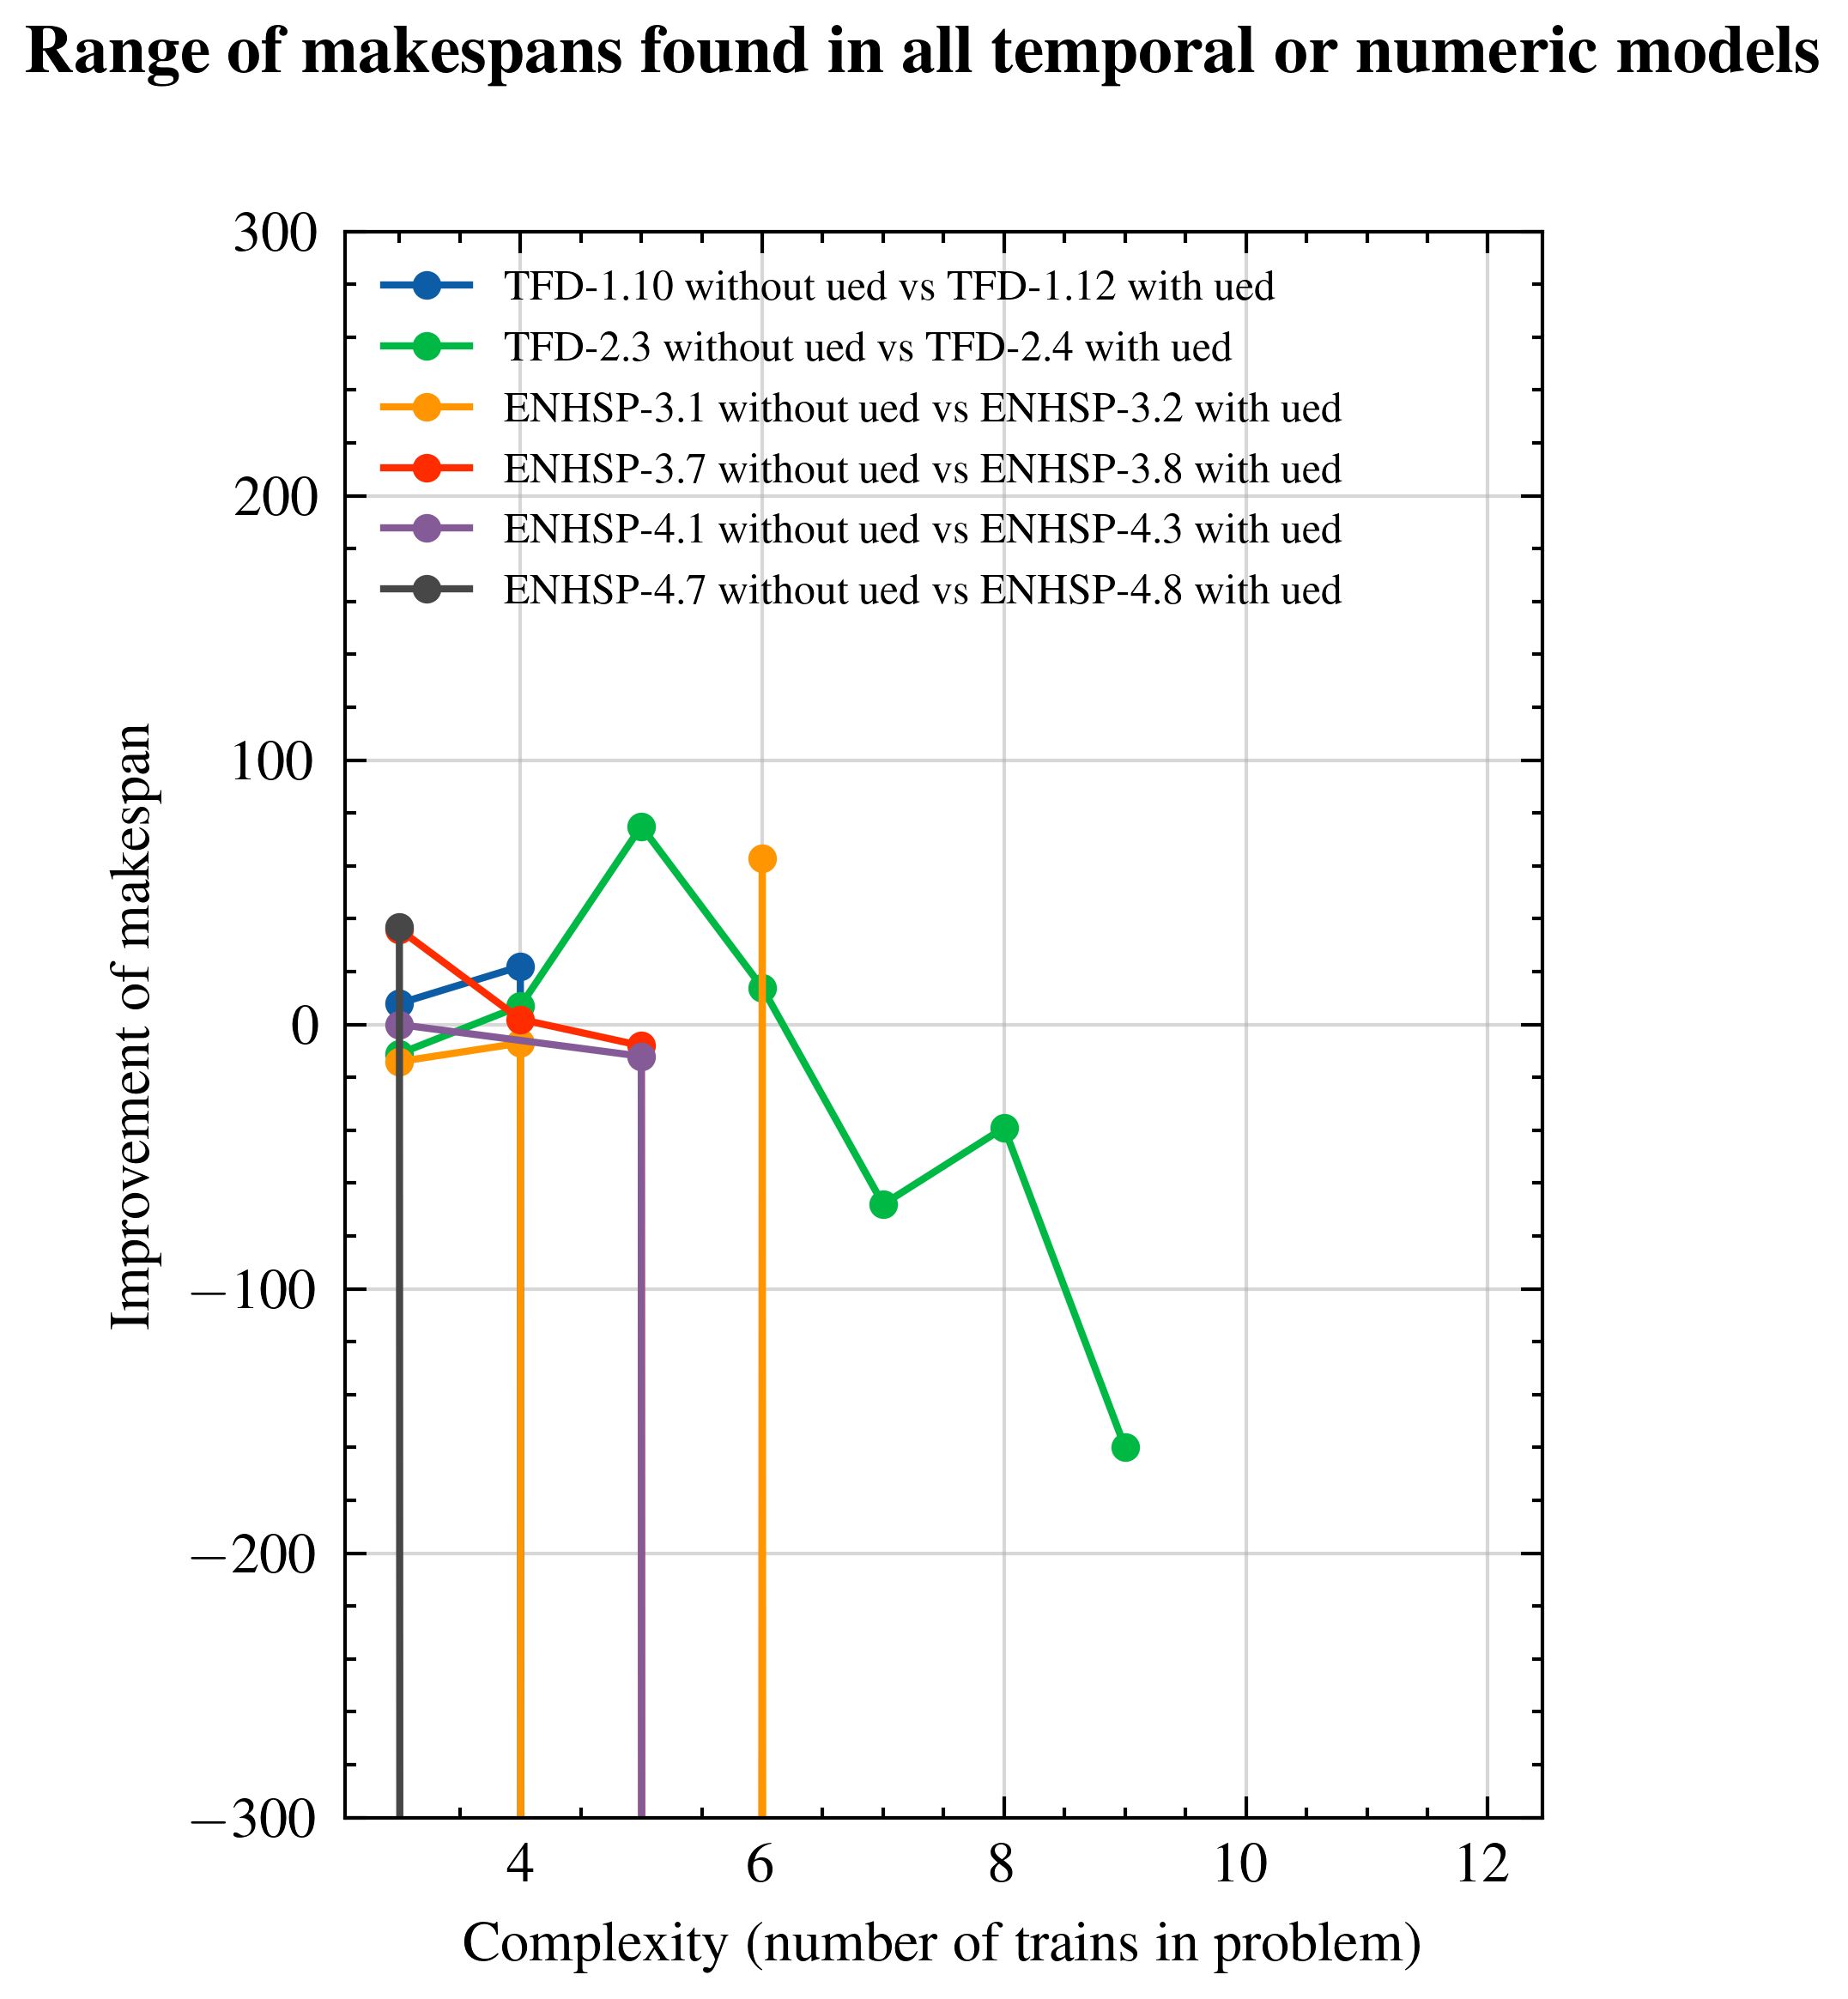

In [5]:
plt.style.use(['ieee', 'science'])

fig, ax = plt.subplots(figsize=(3,4))
fig.suptitle(r"""\textbf{Range of makespans found in all temporal or numeric models}""")

model_pairs = {
    'TFD-1.10 without ued vs TFD-1.12 with ued':{'params':['base1', 10, 12],'x':[], 'vals':[]},
    'TFD-2.3 without ued vs TFD-2.4 with ued':{'params':['base2', 3, 4],'x':[], 'vals':[]}
}

for i in range(3,20):
    for (label, ddict) in model_pairs.items():
        (base, m1, m2) = ddict['params']
        df_normal = df_tfd.query(f'planner == "tfd" and base == "{base}" and config == {m1} and num_trains == {i}')
        df_uniq_ed = df_tfd.query(f'planner == "tfd" and base == "{base}" and config == {m2} and num_trains == {i}')
        if len(df_normal) > 0 or len(df_uniq_ed) > 0:
            model_pairs[label]['x'].append(i)
        if len(df_normal) == 0 and len(df_uniq_ed) > 0:
            model_pairs[label]['vals'].append(100000)
        elif len(df_normal) > 0 and len(df_uniq_ed) == 0:
            model_pairs[label]['vals'].append(-100000)
        elif len(df_normal) > 0 and len(df_uniq_ed) > 0:

            model_pairs[label]['vals'].append(df_normal['makespan_pp'].values[0] - df_uniq_ed['makespan_pp'].values[0])

for label, ddict in model_pairs.items():
    ax.plot(ddict['x'], ddict['vals'], '.-', label=label)

model_pairs = {
    'ENHSP-3.1 without ued vs ENHSP-3.2 with ued':{'params':['base3', 1, 2],'x':[], 'vals':[]},
    'ENHSP-3.7 without ued vs ENHSP-3.8 with ued':{'params':['base3', 7, 8],'x':[], 'vals':[]},
    'ENHSP-4.1 without ued vs ENHSP-4.3 with ued':{'params':['base4', 1, 3],'x':[], 'vals':[]},
    'ENHSP-4.7 without ued vs ENHSP-4.8 with ued':{'params':['base4', 7, 8],'x':[], 'vals':[]},
}


for i in range(3,20):
    for (label, ddict) in model_pairs.items():
        (base, m1, m2) = ddict['params']
        df_normal = df_enhsp.query(f'planner == "enhsp" and base == "{base}" and config == {m1} and num_trains == {i}')
        df_uniq_ed = df_enhsp.query(f'planner == "enhsp" and base == "{base}" and config == {m2} and num_trains == {i}')
        if len(df_normal) > 0 or len(df_uniq_ed) > 0:
            model_pairs[label]['x'].append(i)
        if len(df_normal) == 0 and len(df_uniq_ed) > 0:
            model_pairs[label]['vals'].append(100000)
        elif len(df_normal) > 0 and len(df_uniq_ed) == 0:
            model_pairs[label]['vals'].append(-100000)
        elif len(df_normal) > 0 and len(df_uniq_ed) > 0:

            model_pairs[label]['vals'].append(df_normal['makespan_pp'].values[0] - df_uniq_ed['makespan_pp'].values[0])

for label, ddict in model_pairs.items():
    ax.plot(ddict['x'], ddict['vals'], '.-', label=label)

ax.grid(True, alpha=0.5)
ax.set_ylim((-300,300))
ax.set_ylabel('Improvement of makespan')
ax.set_xlabel('Complexity (number of trains in problem)')
ax.legend(loc='upper left', fontsize=6)

# plt.tight_layout()

fig.savefig('unique_dist_impact.png')

In [4]:
model_pairs

{'ENHSP-3.1 without ued vs ENHSP-3.2 with ued': {'params': ['base3', 1, 2],
  'x': [3, 4, 5, 6, 7, 8, 11],
  'vals': [-14, -7, -100000, 63, -100000, -100000, -100000]},
 'ENHSP-3.7 without ued vs ENHSP-3.8 with ued': {'params': ['base3', 7, 8],
  'x': [3, 4, 5, 6, 7, 8, 9],
  'vals': [36, 2, -8, -100000, -100000, -100000, -100000]},
 'ENHSP-4.1 without ued vs ENHSP-4.3 with ued': {'params': ['base4', 1, 3],
  'x': [3, 5, 6],
  'vals': [0, -12, -100000]},
 'ENHSP-4.7 without ued vs ENHSP-4.8 with ued': {'params': ['base4', 7, 8],
  'x': [3, 4],
  'vals': [37, -100000]}}